<a href="https://colab.research.google.com/github/fl1rry/ecommerce-sales-analysis/blob/main/E_commerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Introduction

This project analyzes e-commerce sales data using SQL, Python, and Tableau. The goal is to understand sales performance across geography, product categories, traffic channels, devices, and user types.

The analysis focuses on the following business questions:

- Which countries and continents generate the highest sales?
- Which product categories are the most profitable?
- Which traffic channels contribute the most to revenue?
- How do sales change over time?
- Are there statistically significant relationships between sessions and sales?
- Do different user groups behave differently in terms of sales?

The final output includes a Jupyter Notebook with data extraction, exploratory analysis, visualizations, pivot tables, and statistical tests, as well as Tableau dashboards.

Link for review: https://public.tableau.com/app/profile/oleksandra.yakovenko/viz/E-commerceSalesPerformanceDashboard_17790298798380/SalesOverview

## Notebook Structure

The analysis is organized into the following sections:

1. Data loading and SQL dataset creation  
2. Dataset overview and data quality check  
3. Business sales analysis  
4. Sales dynamics analysis  
5. Pivot tables and cross-segment analysis  
6. Correlation analysis  
7. Statistical hypothesis testing  
8. Key findings and recommendations  

In [ ]:
from google.colab import auth
auth.authenticate_user()

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [ ]:
from matplotlib.ticker import FuncFormatter

def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'

In [ ]:
project_id = 'data-analytics-mate'

In [ ]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project=project_id)

## 1. Data Extraction and Dataset Creation

The dataset was created using the `session` table as the base table because the analysis should include all website sessions, not only sessions with purchases or registered users.

`LEFT JOIN` was used to enrich sessions with traffic, account, order, and product information while preserving sessions without registered accounts and sessions without purchases.

This join strategy is important because registered users represent only a small share of all sessions, and many sessions do not result in orders.

In [ ]:
query = """
SELECT
  s.date AS order_date,
  s.ga_session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language AS browser_language,
  sp.medium,
  sp.name AS traffic_source,
  sp.channel AS traffic_channel,
  acc.id AS account_id,
  acc.is_verified,
  acc.is_unsubscribed,
  p.category,
  p.name AS product_name,
  p.price,
  p.short_description
FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` acc
  ON acs.account_id = acc.id
LEFT JOIN `data-analytics-mate.DA.order` o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
  ON o.item_id = p.item_id
"""

query_job = client.query(query)

Although the column is named `order_date` in this notebook to match the project task, it is technically based on the session date from the `session` table. Since each purchase is linked to a session, this date is used as the purchase/session date for time-based analysis.

In [ ]:
df = query_job.to_dataframe()

In [ ]:
df.head()

,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,medium,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,category,product_name,price,short_description
0,2020-11-01,967742695,Americas,United States,desktop,Safari,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,9065007548,Asia,China,desktop,Chrome,Safari,Web,None,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3267062634,Americas,United States,desktop,Chrome,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
3,2020-11-01,8892952409,Americas,United States,mobile,Android Webview,<Other>,Web,ko,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,None,None,NaN,None
4,2020-11-01,1624570787,Asia,Turkey,desktop,<Other>,<Other>,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,None,None,NaN,None


The preview confirms that the dataset combines session-level information with geography, device, traffic, account, and product fields. Some sessions contain product information and price, while others have missing product fields, which indicates sessions without purchases.

## 2. Dataset Overview and Data Quality Check

This section checks the size of the dataset, data types, time period, number of unique sessions, missing values, and technical placeholder values.

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

In [ ]:
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

print(f"Number of unique sessions: {df['ga_session_id'].nunique()}\n")

print(f"Date range: from {df['order_date'].min()} to {df['order_date'].max()}\n")

print(f"Number of numeric columns: {len(numeric_cols)}")
print(f'{numeric_cols}\n')

print(f"Number of categorical columns: {len(categorical_cols)}")
print(f'{categorical_cols}\n')

print(f"Number of datetime columns: {len(datetime_cols)}")
print(f'{datetime_cols}\n')

Dataset shape: 349545 rows and 19 columns

Number of unique sessions: 349545

Date range: from 2020-11-01 00:00:00 to 2021-01-31 00:00:00

Number of numeric columns: 5
['ga_session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']

Number of categorical columns: 13
['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'browser_language', 'medium', 'traffic_source', 'traffic_channel', 'category', 'product_name', 'short_description']

Number of datetime columns: 1
['order_date']



The dataset contains **349,545 rows and 19 columns**. There are **349,545 unique sessions**, which means each row represents one session-level record.

The time period covers **2020-11-01 to 2021-01-31**.

The dataset includes:
- **5 numeric columns**: `ga_session_id`, `account_id`, `is_verified`, `is_unsubscribed`, `price`;
- **13 categorical columns** describing geography, device, traffic source, and product information;
- **1 datetime column**: `order_date`.

However, not all numeric columns should be treated as continuous numerical variables. `ga_session_id` and `account_id` are identifiers, while `is_verified` and `is_unsubscribed` are binary indicators. The main continuous numerical variable for sales analysis is `price`.

In [ ]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({'missing_count': missing_values, 'missing_percent': missing_percent})

missing_summary = missing_summary[missing_summary['missing_count'] > 0]
missing_summary.sort_values(by='missing_count', ascending=False)

,missing_count,missing_percent
account_id,321600,92.01
is_verified,321600,92.01
is_unsubscribed,321600,92.01
category,316007,90.41
price,316007,90.41
product_name,316007,90.41
short_description,316007,90.41
browser_language,114266,32.69


Missing values are concentrated in account-related and product-related columns.

The highest missing rates are:

- `account_id`, `is_verified`, `is_unsubscribed`: **321,600 missing values each / 92.01%**
- `category`, `price`, `product_name`, `short_description`: **316,007 missing values each / 90.41%**
- `browser_language`: **114,266 missing values / 32.69%**

Account-related missing values are expected because most users are not registered. Product-related missing values are also expected because only **33,538 sessions out of 349,545** resulted in purchases. Therefore, sessions without purchases do not have product category, product name, price, or product description.

In [ ]:
placeholder_values = ['(data deleted)', 'Undefined', '<Other>', 'None']

placeholder_summary = []

for col in df.columns:
    count = df[col].isin(placeholder_values).sum()
    if count > 0:
        placeholder_summary.append({'column': col, 'placeholder_count': count, 'placeholder_percent': round(count / len(df) * 100, 2)})

placeholder_summary = (pd.DataFrame(placeholder_summary).sort_values(by='placeholder_count', ascending=False))

placeholder_summary

,column,placeholder_count,placeholder_percent
4,traffic_source,87703,25.09
3,medium,72452,20.73
1,mobile_model_name,70839,20.27
5,traffic_channel,21483,6.15
0,browser,8930,2.55
2,operating_system,8673,2.48


The dataset also contains technical placeholder values, such as `(data deleted)`, `Undefined`, and `<Other>`.

The largest placeholder groups are:

- `traffic_source`: **87,703 rows / 25.09%**
- `medium`: **72,452 rows / 20.73%**
- `mobile_model_name`: **70,839 rows / 20.27%**
- `traffic_channel`: **21,483 rows / 6.15%**

These values are not missing from a pandas perspective, but analytically they still mean that part of the information is unavailable, anonymized, undefined, or grouped into a broad bucket. This matters most for traffic analysis: a noticeable share of sessions cannot be fully attributed to a clean source/channel.

In [ ]:
purchase_sessions = df[df['price'].notna()]['ga_session_id'].nunique()
total_sessions = df['ga_session_id'].nunique()

purchase_rate = purchase_sessions / total_sessions * 100

print(f"Sessions with purchases: {purchase_sessions}")
print(f"Purchase session rate: {purchase_rate:.2f}%")

Sessions with purchases: 33538
Purchase session rate: 9.59%


Only **33,538 out of 349,545 sessions** resulted in a purchase, which gives a purchase session rate of **9.59%**.

This means that the dataset is highly session-heavy, while actual purchase events represent a much smaller subset. Therefore, sales-related analysis should be performed on `sales_df`, which includes only sessions with non-missing price values.

For sales analysis, I created a separate dataframe containing only sessions with purchase information.

In [ ]:
sales_df = df[df['price'].notna()].copy()

## 3. Business Sales Analysis

This section analyzes sales performance by geography, product categories, traffic channels, and user type. The goal is to identify the main revenue drivers and understand where sales are concentrated.

### 3.0 Continents by Total Sales and Purchase Sessions

In [ ]:
sales_by_continent = sales_df.groupby('continent', dropna=False)['price'].sum().sort_values(ascending=False).head(5)

sales_by_continent_percent = (sales_by_continent / sales_by_continent.sum() * 100).round(2)

continent_sales_summary = pd.DataFrame({'total_sales': sales_by_continent, 'sales_share_percent': sales_by_continent_percent})

continent_sales_summary

,total_sales,sales_share_percent
continent,,
Americas,17665280.0,55.38
Asia,7601298.3,23.83
Europe,5934624.2,18.61
Oceania,365230.2,1.15
Africa,331231.0,1.04


In [ ]:
continent_orders_summary = sales_df.groupby('continent').agg(purchase_sessions=('ga_session_id', 'nunique')).sort_values('purchase_sessions', ascending=False).head(5)

continent_orders_summary['purchase_sessions_share_percent'] = (continent_orders_summary['purchase_sessions'] / continent_orders_summary['purchase_sessions'].sum() * 100).round(2)

continent_orders_summary

,purchase_sessions,purchase_sessions_share_percent
continent,,
Americas,18553,55.44
Asia,7950,23.75
Europe,6261,18.71
Oceania,364,1.09
Africa,339,1.01


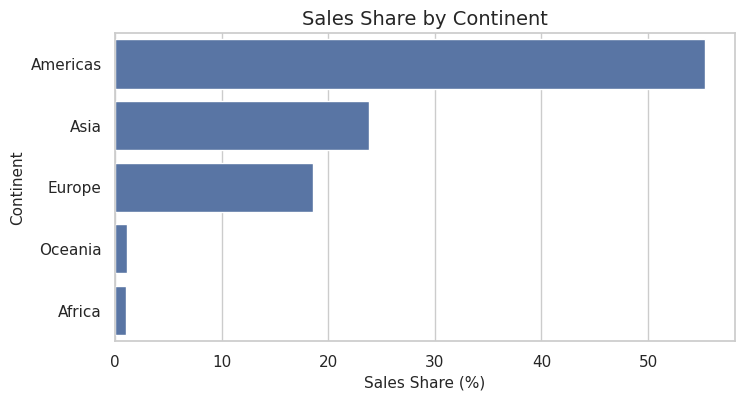

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(x=continent_sales_summary['sales_share_percent'], y=continent_sales_summary.index)
plt.title('Sales Share by Continent')
plt.xlabel('Sales Share (%)')
plt.ylabel('Continent')
plt.show()

Americas is the leading continent-level region by both sales and purchase volume: it generates **55.38%** of total revenue and **55.44%** of purchase sessions. Asia is second with **23.83%** of revenue and **23.75%** of purchase sessions, while Europe contributes **18.61%** of revenue and **18.71%** of purchase sessions.

The revenue and purchase-session shares are almost identical across the top regions. This suggests that the difference between continents is mostly driven by purchase volume, not by a major difference in average purchase value.

### 3.1 Top Countries by Total Sales

In [ ]:
top_countries_sales = sales_df.groupby('country', dropna=False)['price'].sum().sort_values(ascending=False).head(5)

top_countries_sales

,price
country,
United States,13943553.9
India,2809762.0
Canada,2437921.0
United Kingdom,938317.9
France,710692.8


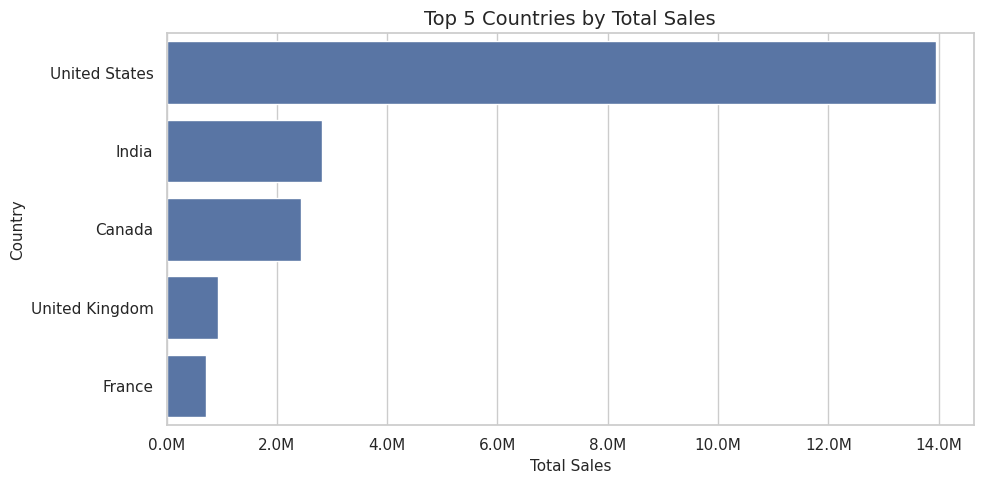

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries_sales.values, y=top_countries_sales.index)
plt.title('Top 5 Countries by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

The United States is the clear revenue leader, generating **43.6%** of total sales on its own. The top 5 countries together account for approximately **65.2%** of total revenue.

This is a strong concentration risk: the business depends heavily on a small number of markets, especially the United States. If performance in the US drops, total sales would likely be affected immediately.

### 3.2 Top Countries by Purchase Sessions

In [ ]:
top_countries_orders = sales_df.groupby('country').agg(purchase_sessions=('ga_session_id', 'nunique')).sort_values(by='purchase_sessions', ascending=False).head(5)

top_countries_orders

,purchase_sessions
country,
United States,14673
India,3029
Canada,2560
United Kingdom,1029
France,678


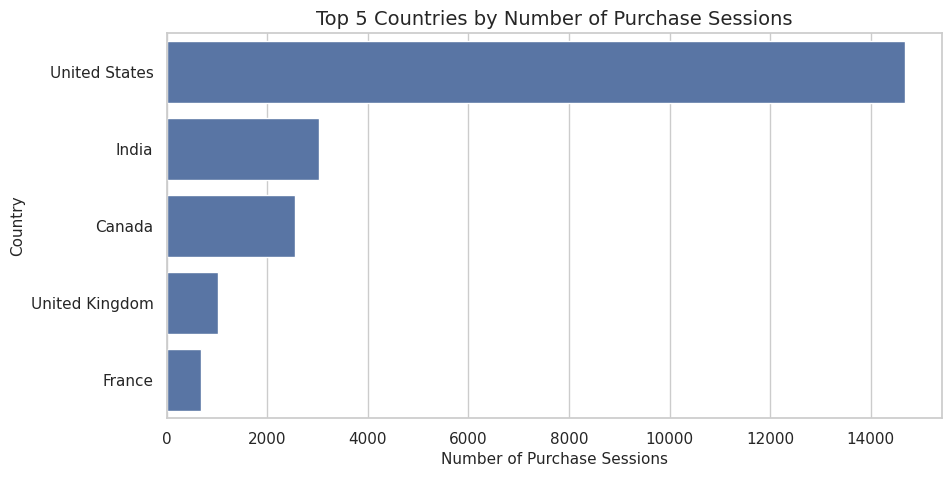

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries_orders.reset_index(), x='purchase_sessions', y='country')
plt.title('Top 5 Countries by Number of Purchase Sessions')
plt.xlabel('Number of Purchase Sessions')
plt.ylabel('Country')

plt.show()

In [ ]:
country_sales_orders = sales_df.groupby('country').agg(total_sales=('price', 'sum'),purchase_sessions=('ga_session_id', 'nunique'))
country_sales_orders['avg_sales_per_purchase_session'] = (country_sales_orders['total_sales'] / country_sales_orders['purchase_sessions'])
country_sales_orders.sort_values('total_sales', ascending=False).head(5)

,total_sales,purchase_sessions,avg_sales_per_purchase_session
country,,,
United States,13943553.9,14673,950.286506
India,2809762.0,3029,927.620337
Canada,2437921.0,2560,952.312891
United Kingdom,938317.9,1029,911.873567
France,710692.8,678,1048.219469


The ranking by purchase sessions is almost the same as the ranking by total sales. The United States has the highest purchase volume with **14,673 purchase sessions**, followed by India, Canada, the United Kingdom, and France.

The interesting part is average sales per purchase session. France has much lower total sales than the United States, India, and Canada, but its average sales per purchase session is the highest among the top 5 countries: **1,048.22**. So France is not the biggest market by volume, but it looks like a higher-value market per purchase session.

### 3.3 Top Product Categories by Total Sales


In [ ]:
top_categories_sales = sales_df.groupby('category', dropna=False)['price'].sum().sort_values(ascending=False).head(10)
top_categories_sales

,price
category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5
Outdoor furniture,2142222.2
Tables & desks,1790307.5
Chests of drawers & drawer units,906562.5
Bar furniture,735503.0


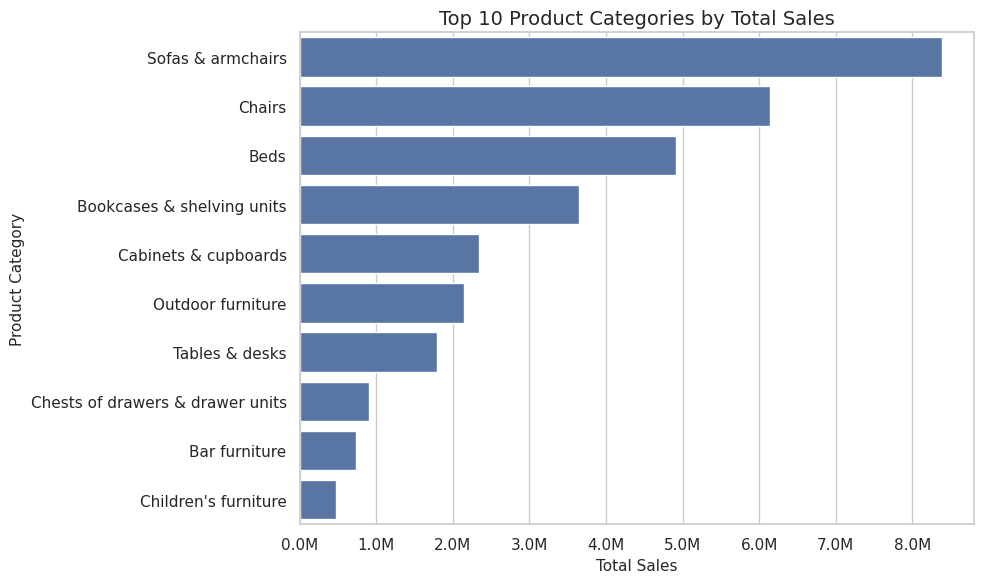

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(x=top_categories_sales.values, y=top_categories_sales.index)
plt.title('Top 10 Product Categories by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

`Sofas & armchairs` is the strongest category by total sales, generating **8,388,254.5**, or about **26.2%** of total revenue. It is followed by `Chairs` (**6,147,748.8 / 19.2%**) and `Beds` (**4,919,725.0 / 15.4%**).

The top three categories together generate more than **60%** of total sales. Revenue is therefore strongly concentrated in a few large furniture categories, especially big-ticket home furniture.

### 3.4 Product Categories in the Top-Performing Country

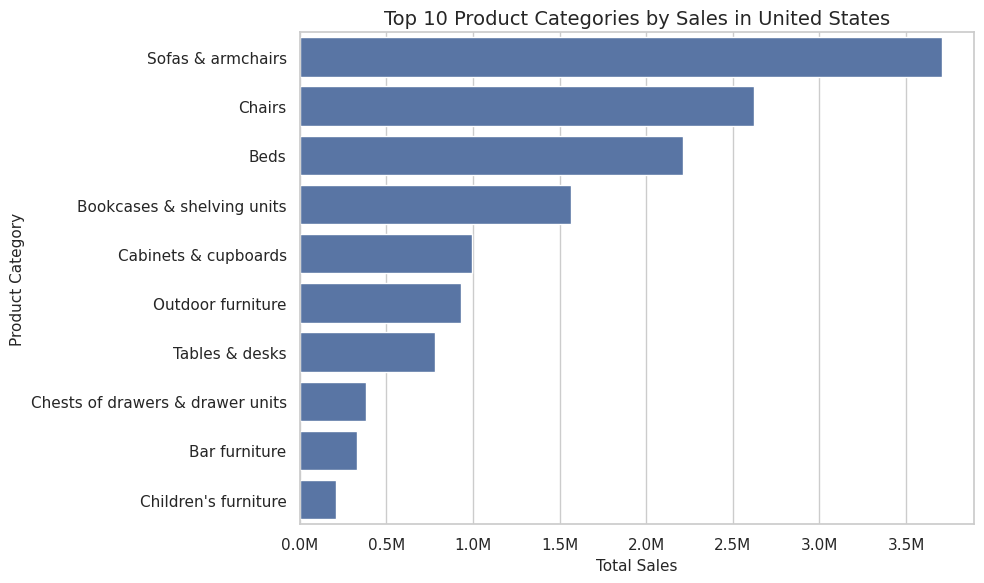

In [ ]:
top_country = sales_df.groupby('country')['price'].sum().idxmax()


top_categories_top_country = sales_df[sales_df['country'] == top_country].groupby('category', dropna=False)['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories_top_country.values, y=top_categories_top_country.index)
plt.title(f'Top 10 Product Categories by Sales in {top_country}')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()

plt.show()

In [ ]:
global_top_categories = set(top_categories_sales.index)
country_top_categories = set(top_categories_top_country.index)

common_categories = global_top_categories.intersection(country_top_categories)
unique_to_top_country = country_top_categories.difference(global_top_categories)

comparison_summary = pd.DataFrame({
    'metric': ['Common categories', 'Categories unique to top country'],
    'count': [len(common_categories), len(unique_to_top_country)]
})

comparison_summary

,metric,count
0,Common categories,10
1,Categories unique to top country,0


The United States is the top-performing country by total sales.

Its top 10 categories fully overlap with the global top 10 categories: **10 common categories and 0 categories unique to the US top 10**. This means the global category ranking is heavily shaped by the US market.

In other words, the United States is not only the largest market by revenue, but also defines the overall product-category picture. If the US category mix changed, the global category ranking would probably change too.

### 3.5 Sales by Traffic Channel


In [ ]:
sales_by_channel = sales_df.groupby('traffic_channel', dropna=False)['price'].sum().sort_values(ascending=False)

sales_by_channel_percent = (sales_by_channel / sales_by_channel.sum() * 100).round(2)

sales_by_channel_summary = pd.DataFrame({
    'total_sales': sales_by_channel,
    'sales_share_percent': sales_by_channel_percent
})

sales_by_channel_summary

,total_sales,sales_share_percent
traffic_channel,,
Organic Search,11433151.6,35.76
Paid Search,8511049.4,26.62
Direct,7494923.4,23.44
Social Search,2532105.7,7.92
Undefined,2000501.0,6.26


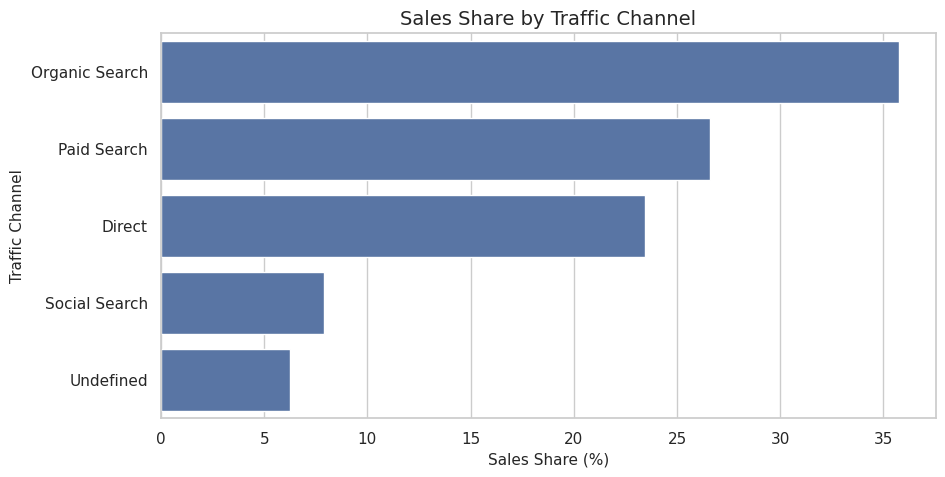

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_channel_summary['sales_share_percent'], y=sales_by_channel_summary.index)
plt.title('Sales Share by Traffic Channel')

plt.xlabel('Sales Share (%)')
plt.ylabel('Traffic Channel')

plt.show()

Organic Search is the largest revenue-generating channel, accounting for **35.76%** of total sales. Paid Search contributes **26.62%**, and Direct contributes **23.44%**.

Together, Organic Search, Paid Search, and Direct generate over **85%** of total sales. Revenue is therefore concentrated in search-driven and direct traffic channels.

One limitation: **6.26%** of sales are assigned to `Undefined`. This is not huge, but it is large enough to mention because it weakens traffic attribution.

### 3.6 Sales by User Type


In [ ]:
sales_df['user_type'] = sales_df['account_id'].notna().map({True: 'Registered', False: 'Unregistered'})

user_type_summary = sales_df.groupby('user_type').agg(total_sales=('price', 'sum'),purchase_sessions=('ga_session_id', 'nunique'))

user_type_summary['avg_sales_per_purchase_session'] = (user_type_summary['total_sales'] / user_type_summary['purchase_sessions'])

user_type_summary = user_type_summary.sort_values('total_sales', ascending=False)
user_type_summary

,total_sales,purchase_sessions,avg_sales_per_purchase_session
user_type,,,
Unregistered,29389212.6,30757,955.529232
Registered,2582518.5,2781,928.629450


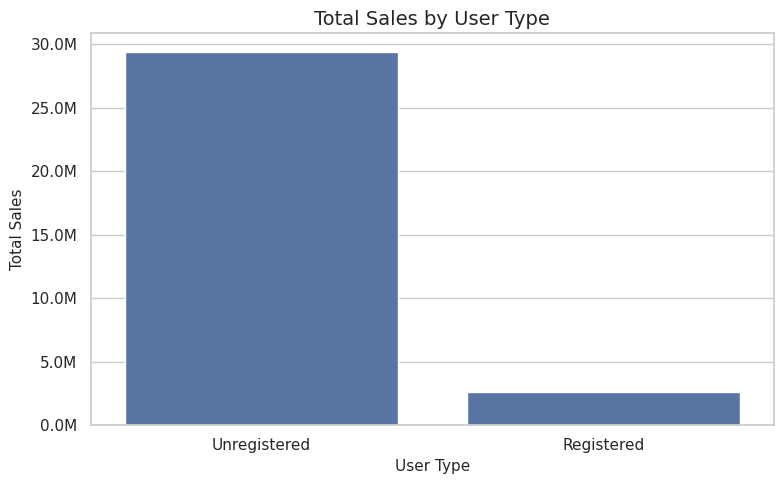

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=user_type_summary.reset_index(), x='user_type', y='total_sales')

plt.title('Total Sales by User Type')
plt.xlabel('User Type')
plt.ylabel('Total Sales')
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

Unregistered users generate **29,389,212.6** in sales, compared with **2,582,518.5** from registered users. That means unregistered users are responsible for about **91.9%** of total sales.

This is expected because most sessions in the dataset are not linked to a registered account. Still, it is an important business finding: the store depends heavily on anonymous traffic.

Average sales per purchase session is also slightly higher for unregistered users (**955.53**) than for registered users (**928.63**). I would not interpret this as “registration lowers purchase value”, it more likely reflects the structure of the dataset, where registered users are a much smaller segment.

## 4. Sales Dynamics Analysis

This section analyzes how sales changed over time. The goal is to identify trends, short-term fluctuations, weekday patterns, and whether sales peaks are driven by specific continents or traffic channels.

### 4.1 Daily Sales Trend


In [ ]:
daily_sales = sales_df.groupby('order_date').agg(total_sales=('price', 'sum'),purchase_sessions=('ga_session_id', 'nunique')).reset_index()

daily_sales.head()

,order_date,total_sales,purchase_sessions
0,2020-11-01,244292.5,281
1,2020-11-02,355506.8,368
2,2020-11-03,498979.6,561
3,2020-11-04,339187.1,370
4,2020-11-05,391276.6,388


In [ ]:
daily_sales['sales_7d_rolling_avg'] = daily_sales['total_sales'].rolling(window=7).mean()
daily_sales.sort_values('total_sales', ascending=False).head(5)

,order_date,total_sales,purchase_sessions,sales_7d_rolling_avg
37,2020-12-08,680509.5,689,449282.985714
39,2020-12-10,624104.6,597,489340.628571
66,2021-01-06,609763.8,579,359509.900000
45,2020-12-16,553134.9,526,488976.671429
38,2020-12-09,551811.6,588,466032.857143


In [ ]:
daily_sales.sort_values('total_sales').head(5)

,order_date,total_sales,purchase_sessions,sales_7d_rolling_avg
6,2020-11-07,200892.2,215,336111.000000
14,2020-11-15,209535.5,225,287218.942857
13,2020-11-14,214889.3,228,288879.942857
61,2021-01-01,217984.9,217,276630.785714
7,2020-11-08,221162.5,223,332806.714286


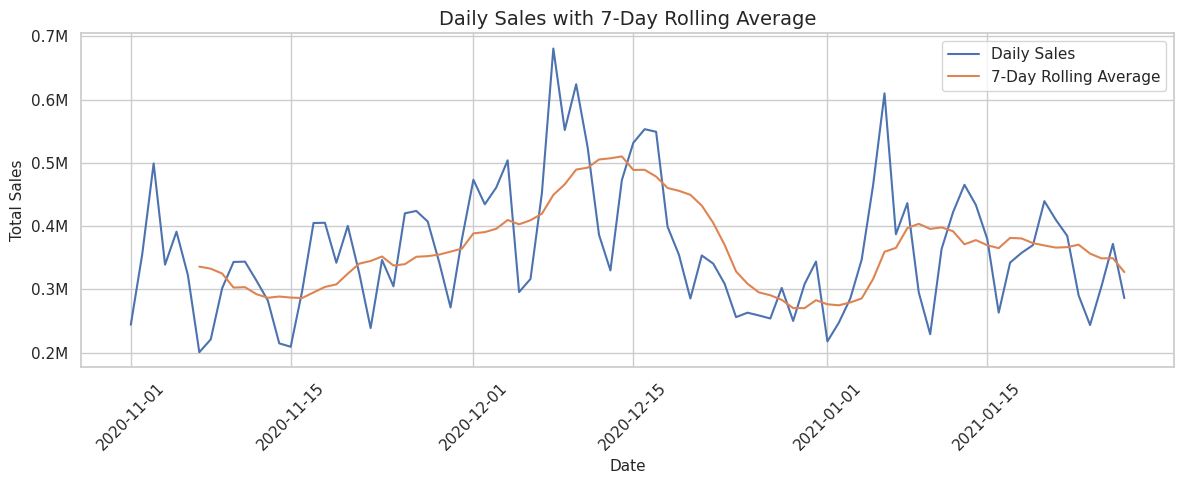

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=daily_sales, x='order_date', y='total_sales', label='Daily Sales')

sns.lineplot(data=daily_sales, x='order_date', y='sales_7d_rolling_avg', label='7-Day Rolling Average')
plt.title('Daily Sales with 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

Daily sales are quite volatile during the analyzed period, so I added a 7-day rolling average to make the trend easier to read.

The highest daily sales were recorded on **2020-12-08**, with total sales of **680,509.5**. The lowest daily sales were recorded on **2020-11-07**, with total sales of **200,892.2**.

The rolling average shows a stronger sales period around early-to-mid December, followed by weaker performance around the start of January. Since the dataset covers only three months, I would treat this as short-term movement rather than confirmed long-term seasonality.

### 4.2 Weekday Sales Pattern


In [ ]:
daily_sales['weekday'] = daily_sales['order_date'].dt.day_name()
daily_sales['weekday_num'] = daily_sales['order_date'].dt.dayofweek

weekday_sales = daily_sales.groupby(['weekday_num', 'weekday']).agg(avg_daily_sales=('total_sales', 'mean')).reset_index().sort_values('weekday_num')

weekday_sales.sort_values('avg_daily_sales', ascending=False)

,weekday_num,weekday,avg_daily_sales
2,2,Wednesday,420503.300000
1,1,Tuesday,419808.915385
3,3,Thursday,411411.300000
4,4,Friday,376922.266667
0,0,Monday,356637.723077
5,5,Saturday,289832.575000
6,6,Sunday,267183.707692


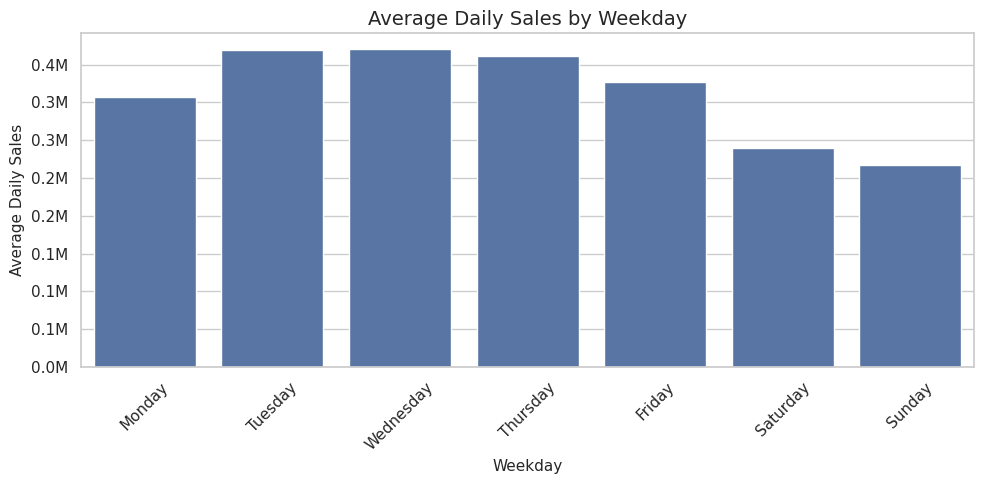

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_sales, x='weekday', y='avg_daily_sales')
plt.title('Average Daily Sales by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Daily Sales')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()

plt.show()

Wednesday has the highest average daily sales (**420,503.3**), followed very closely by Tuesday (**419,808.9**) and Thursday (**411,411.3**). Weekend sales are noticeably weaker: Saturday averages **289,832.6**, and Sunday averages **267,183.7**.

This suggests that sales are stronger in the middle of the week and weaker on weekends. Because the dataset covers only three months, I would treat this as a short-term weekday pattern, not as confirmed seasonality.

### 4.3 Daily Sales Dynamics by Top 3 Continents


In [ ]:
top_3_continents = sales_df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3).index

daily_sales_continent = sales_df[sales_df['continent'].isin(top_3_continents)].groupby(['order_date', 'continent']).agg(total_sales=('price', 'sum')).reset_index()

top_3_continents

Index(['Americas', 'Asia', 'Europe'], dtype='object', name='continent')

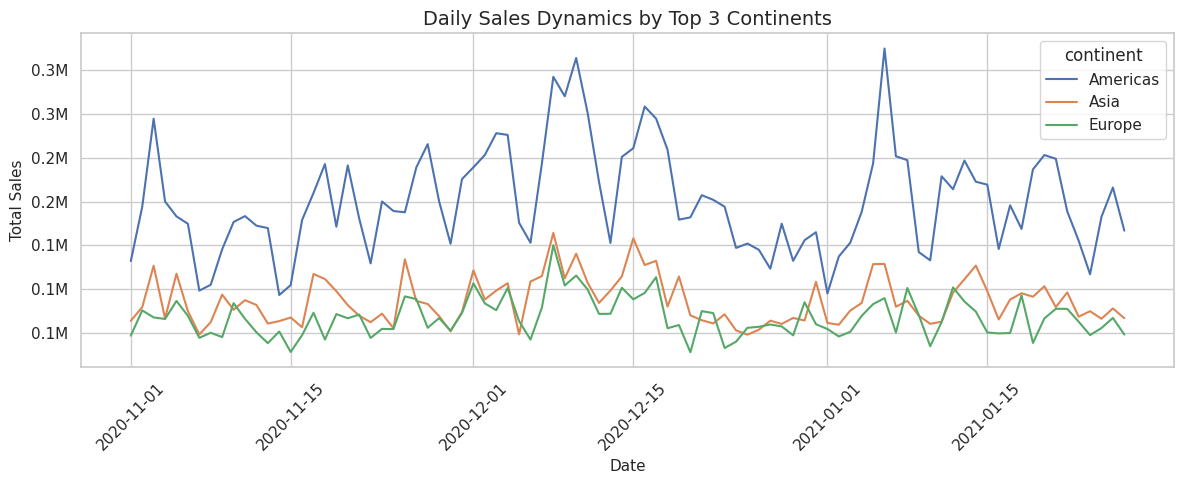

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_sales_continent, x='order_date', y='total_sales', hue='continent')
plt.title('Daily Sales Dynamics by Top 3 Continents')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

The top three continents by total sales are **Americas, Asia, and Europe**.

Americas is consistently the strongest region across the period and drives most visible sales peaks. Asia and Europe move at lower levels but follow a broadly similar pattern. This supports the earlier geography analysis: total sales are mostly shaped by the Americas, while Asia and Europe act as secondary revenue regions.

### 4.4 Daily Sales Dynamics by Traffic Channel

In [ ]:
top_channels = sales_df.groupby('traffic_channel')['price'].sum().sort_values(ascending=False).head(4).index

daily_sales_channel = sales_df[sales_df['traffic_channel'].isin(top_channels)].groupby(['order_date', 'traffic_channel']).agg(total_sales=('price', 'sum')).reset_index()

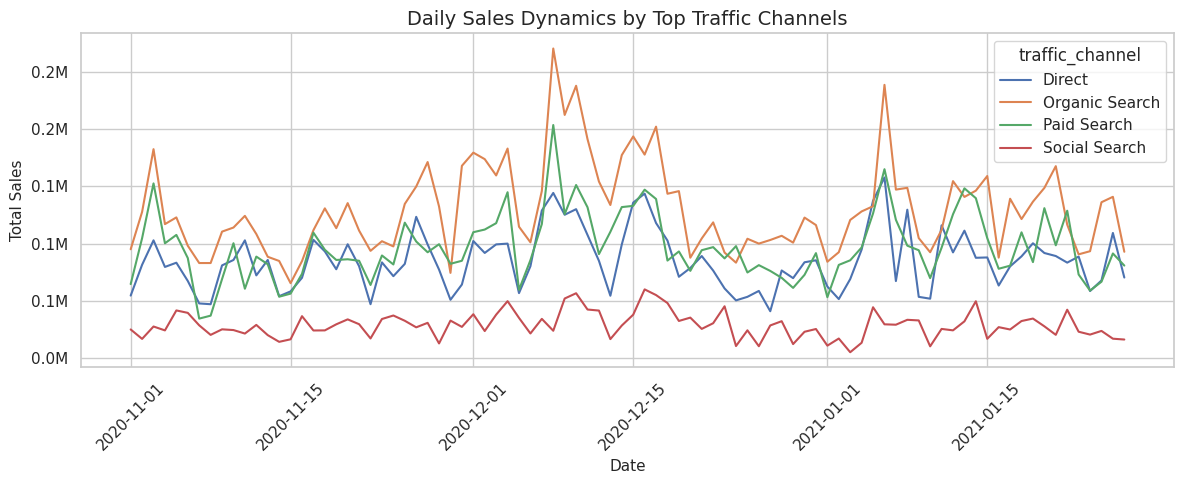

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_sales_channel, x='order_date', y='total_sales', hue='traffic_channel')
plt.title('Daily Sales Dynamics by Top Traffic Channels')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

Organic Search, Paid Search, Direct, and Social Search were selected as the top traffic channels by revenue.

Organic Search stays the strongest channel across most of the period. The largest sales peaks usually happen together with increases in Organic Search and Paid Search, which supports the earlier finding that search-driven channels are the main revenue drivers.

Social Search behaves more separately and stays much smaller in volume, so I would not treat it as a core revenue channel based on this dataset.

## 5. Pivot Tables and Cross-Segment Analysis

Pivot tables were used to analyze sales and sessions across multiple dimensions at the same time. This helps identify segment-level patterns that are not visible in one-dimensional charts.

### 5.1 Sessions by Traffic Channel and Device Type

In [ ]:
sessions_pivot = pd.pivot_table(df[df['traffic_channel'].notna() & df['device'].notna()],
    values='ga_session_id',
    index='traffic_channel',
    columns='device',
    aggfunc='nunique',
    fill_value=0
)

sessions_pivot

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


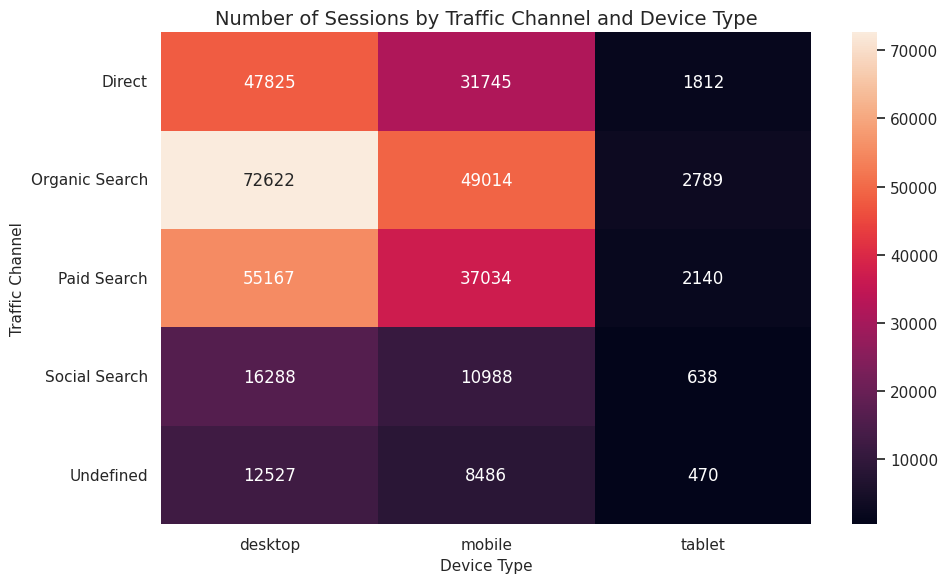

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(sessions_pivot, annot=True, fmt='.0f')
plt.title('Number of Sessions by Traffic Channel and Device Type')
plt.xlabel('Device Type')
plt.ylabel('Traffic Channel')
plt.tight_layout()
plt.show()

Desktop is the dominant device type across every traffic channel. Organic Search brings the highest number of sessions on desktop, mobile, and tablet.

This means Organic Search is not only the strongest revenue channel, but also the largest acquisition channel by sessions. Tablet traffic is very small compared with desktop and mobile, so it is unlikely to be a major business driver in this dataset.

### 5.2 Sales by Product Category and Country


In [ ]:
top_10_categories = sales_df.groupby('category')['price'].sum().sort_values(ascending=False).head(10).index

top_5_countries = sales_df.groupby('country')['price'].sum().sort_values(ascending=False).head(5).index

category_country_pivot = pd.pivot_table(sales_df[sales_df['category'].isin(top_10_categories) & sales_df['country'].isin(top_5_countries)],
    values='price',
    index='category',
    columns='country',
    aggfunc='sum',
    fill_value=0)

category_country_pivot

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


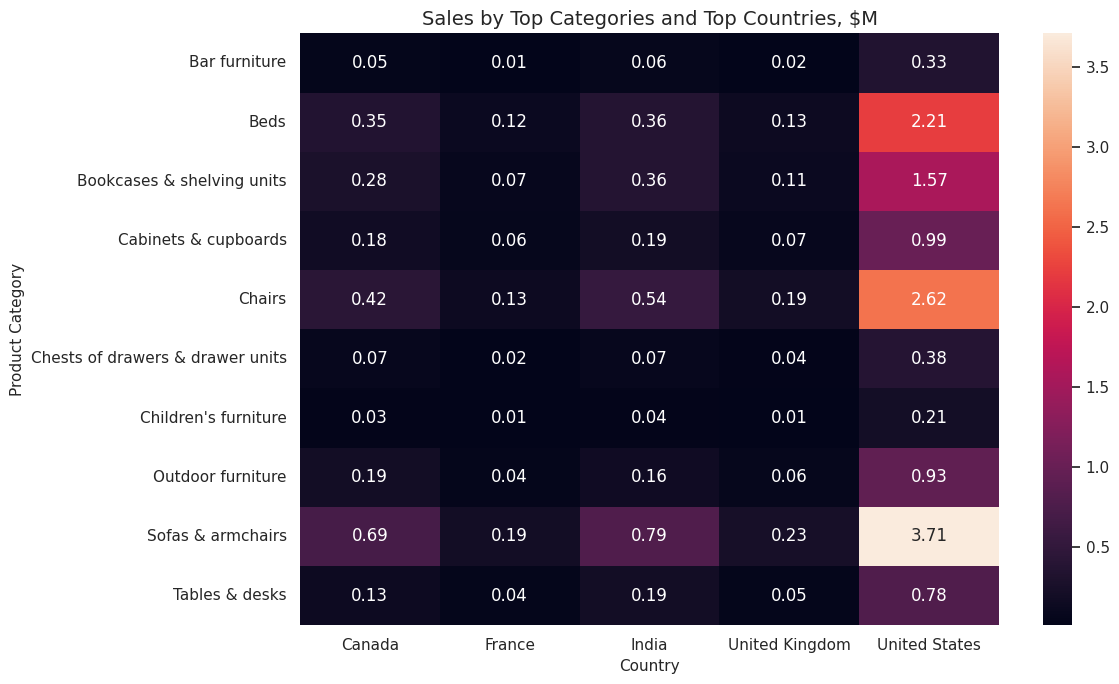

In [ ]:
plt.figure(figsize=(12, 7))
sns.heatmap(category_country_pivot / 1_000_000, annot=True, fmt='.2f')
plt.title('Sales by Top Categories and Top Countries, $M')
plt.xlabel('Country')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

The United States dominates sales across nearly all top product categories.

The strongest category-country combination is **Sofas & armchairs in the United States**, with sales of **3,707,144.5**. Other major combinations are also US-based, especially `Chairs` and `Beds`.

This confirms two things: first, the United States is the key revenue market; second, large furniture categories are the main sales drivers. The business is not evenly distributed across countries or product categories. It is concentrated in a few high-impact segments.

### 5.3 Sales by Traffic Channel and User Type

In [ ]:
traffic_user_pivot = pd.pivot_table(sales_df, values='price', index='traffic_channel', columns='user_type', aggfunc='sum', fill_value=0)

traffic_user_pivot

user_type,Registered,Unregistered
traffic_channel,,
Direct,608937.2,6885986.2
Organic Search,934329.5,10498822.1
Paid Search,640799.6,7870249.8
Social Search,205139.9,2326965.8
Undefined,193312.3,1807188.7


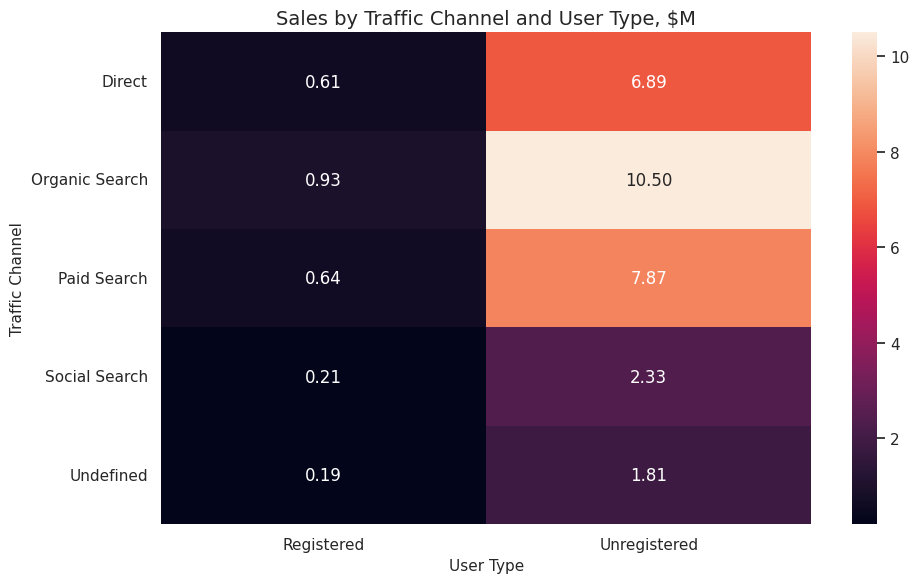

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(traffic_user_pivot/ 1_000_000, annot=True, fmt='.2f')
plt.title('Sales by Traffic Channel and User Type, $M')
plt.xlabel('User Type')
plt.ylabel('Traffic Channel')
plt.tight_layout()
plt.show()

Across every traffic channel, unregistered users generate much higher sales than registered users. Organic Search is the strongest channel for both user types.

The main takeaway is not just that unregistered users buy more in total. That was expected from the dataset structure. The more useful point is that anonymous revenue is spread across all major channels, especially Organic Search, Paid Search, and Direct. Any registration or login changes should therefore be tested carefully, because too much friction could affect the largest revenue segment.

## 6. Correlation Analysis

This section examines whether key sales metrics move together over time. Correlation analysis helps understand whether daily sales are associated with daily sessions, and whether sales patterns across regions and channels are synchronized.

### 6.1 Relationship Between Daily Sessions and Daily Sales


In [ ]:
daily_metrics = df.groupby('order_date').agg(sessions=('ga_session_id', 'nunique'), total_sales=('price', 'sum')).reset_index()

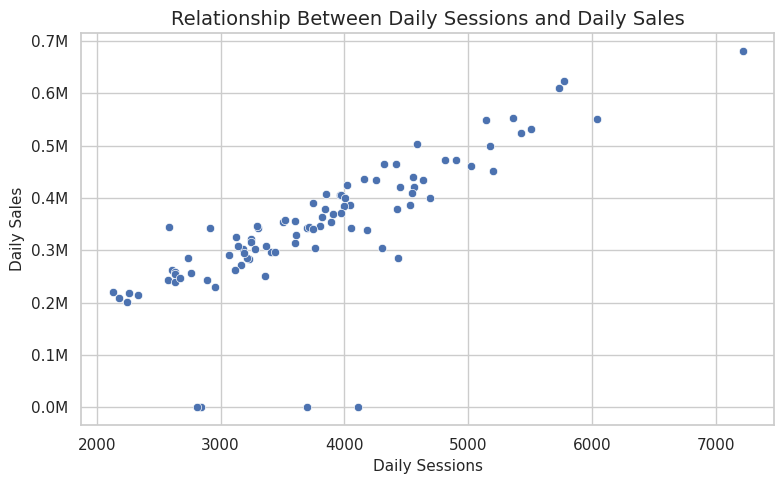

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=daily_metrics, x='sessions', y='total_sales')
plt.title('Relationship Between Daily Sessions and Daily Sales')
plt.xlabel('Daily Sessions')
plt.ylabel('Daily Sales')
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

In [ ]:
corr, p_value = stats.pearsonr(daily_metrics['sessions'], daily_metrics['total_sales'])

corr, p_value

(np.float64(0.7910809164540891), np.float64(6.483532312080735e-21))

Pearson correlation was used to test the relationship between daily sessions and daily sales.

The correlation coefficient is **0.791**, with a p-value of **6.48e-21**. This is a strong positive and statistically significant relationship: days with more sessions tend to have higher sales.

I would still avoid treating this as causation. More sessions are associated with more sales, but the analysis does not prove that sessions alone cause sales growth. Traffic quality, product mix, promotions, and channel structure can also affect revenue.

### 6.2 Correlation of Sales Between Top Continents

In [ ]:
continent_daily_sales = (sales_df[sales_df['continent'].isin(top_3_continents)].pivot_table(
        index='order_date',
        columns='continent',
        values='price',
        aggfunc='sum',
        fill_value=0
    )
)

continent_daily_sales.corr()

continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.692273,0.669527
Asia,0.692273,1.000000,0.667786
Europe,0.669527,0.667786,1.000000


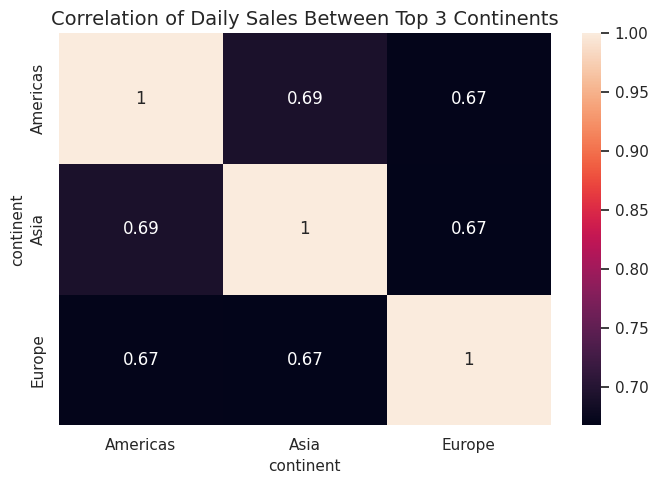

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(continent_daily_sales.corr(), annot=True)
plt.title('Correlation of Daily Sales Between Top 3 Continents')
plt.tight_layout()
plt.show()

In [ ]:
correlation_results_continent = []

for col1 in continent_daily_sales.columns:
    for col2 in continent_daily_sales.columns:
        if col1 < col2:
            corr, p = stats.pearsonr(continent_daily_sales[col1], continent_daily_sales[col2])
            correlation_results_continent.append({
                'variable_1': col1,
                'variable_2': col2,
                'correlation': round(corr, 3),
                'p_value': p
            })

pd.DataFrame(correlation_results_continent)

,variable_1,variable_2,correlation,p_value
0,Americas,Asia,0.692,8.004063e-14
1,Americas,Europe,0.670,9.911408e-13
2,Asia,Europe,0.668,1.190893e-12


Daily sales between the top three continents show moderate-to-strong positive correlations:

- Americas and Asia: **r = 0.692**, p-value = **8.00e-14**
- Americas and Europe: **r = 0.670**, p-value = **9.91e-13**
- Asia and Europe: **r = 0.668**, p-value = **1.19e-12**

All three relationships are statistically significant. This means sales in the major regions tend to move in the same direction over time. The pattern may reflect shared global demand, similar weekday effects, or global campaigns, but the correlation alone does not prove the exact cause.

### 6.3 Correlation of Sales Between Traffic Channels

In [ ]:
channel_daily_sales = sales_df[sales_df['traffic_channel'].isin(top_channels)].pivot_table(
        index='order_date',
        columns='traffic_channel',
        values='price',
        aggfunc='sum',
        fill_value=0)

channel_daily_sales.corr()

traffic_channel,Direct,Organic Search,Paid Search,Social Search
traffic_channel,,,,
Direct,1.000000,0.759938,0.724343,0.461895
Organic Search,0.759938,1.000000,0.808234,0.434424
Paid Search,0.724343,0.808234,1.000000,0.452287
Social Search,0.461895,0.434424,0.452287,1.000000


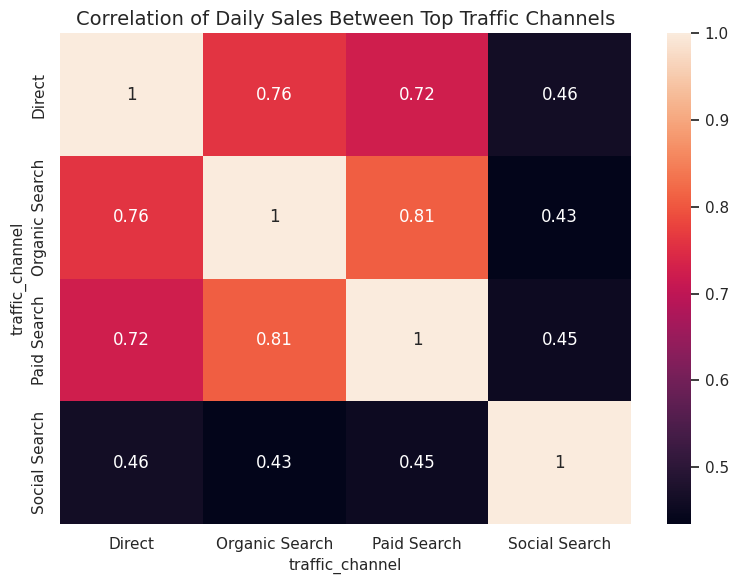

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(channel_daily_sales.corr(), annot=True)
plt.title('Correlation of Daily Sales Between Top Traffic Channels')
plt.tight_layout()
plt.show()

In [ ]:
correlation_results = []

for col1 in channel_daily_sales.columns:
    for col2 in channel_daily_sales.columns:
        if col1 < col2:
            corr, p = stats.pearsonr(channel_daily_sales[col1], channel_daily_sales[col2])
            correlation_results.append({
                'variable_1': col1,
                'variable_2': col2,
                'correlation': round(corr, 3),
                'p_value': p
            })

pd.DataFrame(correlation_results)

,variable_1,variable_2,correlation,p_value
0,Direct,Organic Search,0.760,9.107881e-18
1,Direct,Paid Search,0.724,1.512880e-15
2,Direct,Social Search,0.462,5.901047e-06
3,Organic Search,Paid Search,0.808,1.755643e-21
4,Organic Search,Social Search,0.434,2.347593e-05
5,Paid Search,Social Search,0.452,9.696038e-06


The strongest channel-level correlation is between **Organic Search and Paid Search** (**r = 0.808**). Direct traffic is also strongly correlated with both Organic Search and Paid Search.

Social Search has weaker correlations with the other channels, around **0.43–0.46**. This suggests that Social Search does not follow the same sales pattern as the more intent-driven channels.

From a business point of view, Organic Search, Paid Search, and Direct seem to move together more closely, while Social Search behaves more independently and contributes less revenue overall.

## 7. Statistical Hypothesis Testing

This section tests whether observed differences between groups are statistically significant. For each test, the hypotheses, test choice, p-value, and conclusion are provided.

### 7.1 Registered vs Unregistered Users: Daily Sales Comparison

In [ ]:
daily_sales_user_type = sales_df.groupby(['order_date', 'user_type']).agg(total_sales=('price', 'sum')).reset_index()

registered_sales = daily_sales_user_type[daily_sales_user_type['user_type'] == 'Registered']['total_sales']

unregistered_sales = daily_sales_user_type[daily_sales_user_type['user_type'] == 'Unregistered']['total_sales']

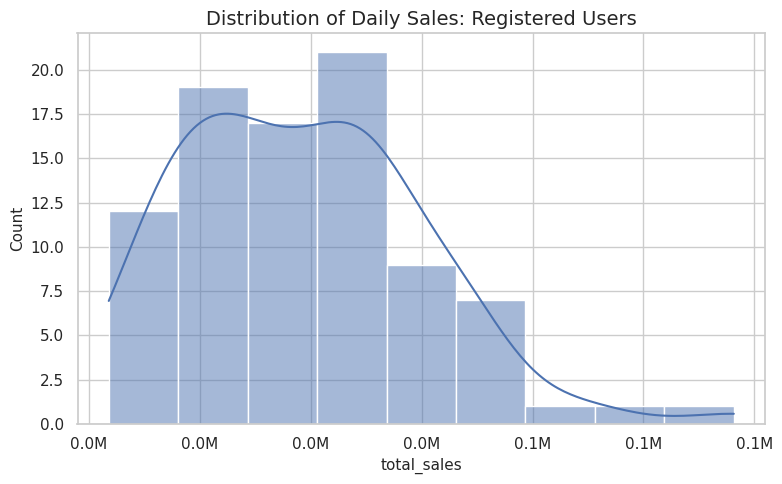

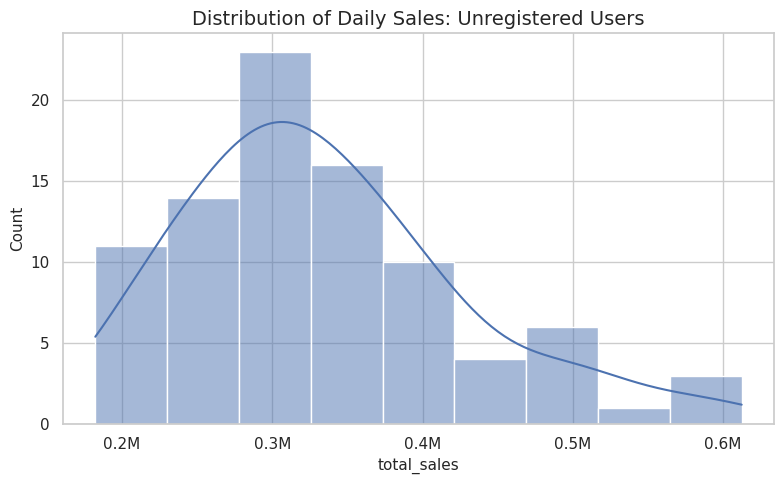

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(registered_sales, kde=True)
plt.title('Distribution of Daily Sales: Registered Users')
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(unregistered_sales, kde=True)
plt.title('Distribution of Daily Sales: Unregistered Users')
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

In [ ]:
registered_shapiro = stats.shapiro(registered_sales)
unregistered_shapiro = stats.shapiro(unregistered_sales)

print("Registered users:", registered_shapiro)
print("Unregistered users:", unregistered_shapiro)

print("Registered median:", registered_sales.median())
print("Unregistered median:", unregistered_sales.median())

Registered users: ShapiroResult(statistic=np.float64(0.9591810175035426), pvalue=np.float64(0.007295139880540744))
Unregistered users: ShapiroResult(statistic=np.float64(0.9521579282190968), pvalue=np.float64(0.0026183359245325936))
Registered median: 28048.0
Unregistered median: 316724.25


In [ ]:
stat, p_value = stats.mannwhitneyu(registered_sales, unregistered_sales, alternative='two-sided')

stat, p_value

(np.float64(0.0), np.float64(2.2159276950123465e-30))

**H0:** There is no statistically significant difference in daily sales between registered and unregistered users.  
**H1:** There is a statistically significant difference in daily sales between registered and unregistered users.

The distributions were checked before choosing the test. Since normality cannot be safely assumed for either group, I used the Mann-Whitney U test instead of a t-test.

The test returned a p-value of **2.22e-30**, which is far below 0.05. Therefore, I reject the null hypothesis.

The difference is not only statistically significant, but also practically large: median daily sales are **316,724.25** for unregistered users versus **28,048.0** for registered users. This supports the earlier finding that most revenue comes from anonymous users.

### 7.2 Differences in Daily Sessions Between Traffic Channels

In [ ]:
daily_sessions_channel = df.groupby(['order_date', 'traffic_channel']).agg(sessions=('ga_session_id', 'nunique')).reset_index()

top_channel_sessions = daily_sessions_channel[daily_sessions_channel['traffic_channel'].isin(top_channels)]

groups = [group['sessions'].values for name, group in top_channel_sessions.groupby('traffic_channel')]

stat, p_value = stats.kruskal(*groups)
stat, p_value

(np.float64(260.481538647879), np.float64(3.5370311010399424e-56))

In [ ]:
top_channel_sessions.groupby('traffic_channel')['sessions'].agg(['median', 'mean', 'min', 'max']).sort_values('median', ascending=False)

,median,mean,min,max
traffic_channel,,,,
Organic Search,1329.0,1352.445652,733,2589
Paid Search,989.0,1025.445652,578,1959
Direct,869.5,884.586957,481,1668
Social Search,308.0,303.413043,137,561


**H0:** Daily session counts are the same across traffic channels.  
**H1:** At least one traffic channel has a different distribution of daily session counts.

Because there are more than two independent groups and normality cannot be safely assumed, I used the Kruskal-Wallis test.

The test returned a p-value of **3.54e-56**, which is far below 0.05. Therefore, I reject the null hypothesis.

The descriptive statistics support the test result: Organic Search has the highest median number of daily sessions (**1,329**), followed by Paid Search (**989**) and Direct (**869.5**). Social Search is much lower, with a median of **308** sessions. So the channels differ not only statistically, but also in practical volume.

### 7.3 Organic Traffic Share: Europe vs Americas

In [ ]:
organic_region_df = df[df['continent'].isin(['Europe', 'Americas'])].copy()

organic_region_df['is_organic'] = organic_region_df['traffic_channel'].eq('Organic Search')

In [ ]:
organic_table = pd.crosstab(
    organic_region_df['continent'],
    organic_region_df['is_organic']
)

organic_table

is_organic,False,True
continent,,
Americas,124508,68671
Europe,41940,23195


In [ ]:
organic_share = organic_table[True] / organic_table.sum(axis=1) * 100
organic_share.round(2)

,0
continent,
Americas,35.55
Europe,35.61


In [ ]:
chi2, p_value, dof, expected = stats.chi2_contingency(organic_table)

chi2, p_value, dof

(np.float64(0.08110059225974814), np.float64(0.7758114260479175), 1)

**H0:** Organic traffic share is independent of continent.  
**H1:** Organic traffic share differs between Europe and Americas.

A chi-square test of independence was used because both variables are categorical: continent and organic/non-organic traffic type.

The organic traffic share is almost identical in both regions: **35.55%** in Americas and **35.61%** in Europe. The p-value is **0.776**, which is higher than 0.05, so I fail to reject the null hypothesis.

There is no statistically significant evidence that Organic Search has a different share in Europe compared with Americas. In this case, the non-significant result makes sense because the observed percentages are nearly the same.

## 8. Key Findings and Business Recommendations

The dataset contains **349,545 sessions**, but only **33,538 sessions** resulted in purchases. The purchase session rate is **9.59%**, so most sessions are browsing sessions without product/order information.

### Key Findings

1. **Sales are highly concentrated geographically.**  
   Americas generates **55.38%** of total revenue, and the United States alone generates **43.6%** of total sales. The top 5 countries account for approximately **65.2%** of total revenue.

2. **The United States is the main business driver.**  
   It generated **13,943,553.9** in revenue and **14,673 purchase sessions**. Its top 10 product categories fully overlap with the global top 10, meaning the US market strongly shapes the overall category ranking.

3. **Revenue is concentrated in a few product categories.**  
   `Sofas & armchairs`, `Chairs`, and `Beds` together generate more than **60%** of total revenue. This means large furniture categories are the core revenue drivers.

4. **Organic Search is the strongest traffic channel.**  
   It accounts for **35.76%** of total sales, followed by Paid Search (**26.62%**) and Direct (**23.44%**). Together, these three channels generate over **85%** of total sales.

5. **Unregistered users generate most of the revenue.**  
   Unregistered users account for about **91.9%** of total sales. This does not mean registration is bad, but it does mean anonymous traffic is the main revenue segment in this dataset.

6. **Daily sessions and daily sales are strongly related.**  
   The Pearson correlation between daily sessions and daily sales is **0.791**, with a statistically significant p-value. More traffic is associated with more revenue, although this should not be interpreted as direct causation.

7. **Traffic channels differ significantly in session volume.**  
   The Kruskal-Wallis test confirms that daily sessions are not distributed equally across channels. Organic Search has the highest median daily sessions, followed by Paid Search and Direct.

### Business Recommendations

1. **Prioritize the United States market.**  
   The US is the largest revenue market and strongly influences global category rankings. Product and marketing decisions for this market will likely have the biggest impact on total sales.

2. **Protect and improve Organic Search performance.**  
   Organic Search is the largest revenue channel and the largest session acquisition channel. It should be treated as a core growth channel, not just a free traffic source.

3. **Monitor Paid Search efficiency separately.**  
   Paid Search generates a large share of revenue, but high revenue does not automatically mean high profitability. Cost data would be needed to evaluate whether this channel is efficient.

4. **Improve traffic attribution quality.**  
   A meaningful share of sessions and sales is assigned to `Undefined` or anonymized traffic values. Cleaner attribution would make channel-level decisions more reliable.

5. **Be careful with registration friction.**  
   Since most revenue comes from unregistered users, forcing registration too early could hurt conversion. Any registration-related changes should be A/B tested before rollout.

6. **Use category-country analysis for product strategy.**  
   The strongest revenue combinations are concentrated in the US and in large furniture categories. These segments should be monitored separately because they drive a large part of total revenue.

### Data Limitations

- The dataset covers only three months, so long-term seasonality cannot be confirmed.
- The date field is based on the session date. Therefore, time-based sales analysis should be interpreted as session/purchase-date analysis rather than confirmed order timestamp analysis.
- Some traffic source information is anonymized, undefined, or grouped into placeholder values.
- Many account-related fields are missing because most users are not registered.
- Product information is missing for sessions without purchases.
- Revenue is analyzed without cost or margin data, so channel profitability cannot be evaluated.